# Что влияет на возврат кредита: анализ 1 000 займов

Выпускной проект курса «Аналитик данных» (BELHARD, 2026).

**Задача.** По данным о клиентах и выданных кредитах понять, какие признаки клиента
и кредита связаны с дефолтом, и отделить реальные закономерности от случайных различий.

**Стек:** SQL (PostgreSQL / Supabase), Python — pandas, seaborn, SciPy, statsmodels.

**Коротко о результате.** Цель кредита, семейное положение, доход и возраст
статистически значимо на дефолт не влияют, хотя в сводных таблицах разница между
группами доходит до 14 п. п. Единственный значимый, но слабый фактор — срок кредита.

## 1. Данные

Две таблицы в PostgreSQL: `clients` (анкета клиента) и `loans` (параметры кредита
и флаг дефолта). Витрина для анализа собрана SQL-запросом:

```sql
SELECT c.client_id, l.loan_id, l.loan_purpose, l.loan_amount, l.interest_rate,
       l.term_months, l.default_flag, c.age, c.family_status, c.children,
       c.employment_years, c.income
FROM loans AS l
JOIN clients AS c ON l.client_id = c.client_id;
```

Агрегат по группам на стороне базы:

```sql
SELECT loan_purpose, family_status,
       COUNT(loan_id)                                           AS total_loans,
       SUM(CASE WHEN default_flag = 0 THEN 1 END)               AS repaid_loans,
       ROUND(SUM(CASE WHEN default_flag = 0 THEN 1 END) * 100.0
             / COUNT(loan_id), 2)                               AS repayment_rate,
       ROUND(AVG(loan_amount), 2)                               AS avg_loan_amount,
       ROUND(AVG(income), 2)                                    AS avg_income
FROM loans AS l
JOIN clients AS c ON l.client_id = c.client_id
GROUP BY loan_purpose, family_status
ORDER BY loan_purpose, family_status;
```

Данные учебные, выданы в рамках курса.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.formula.api import ols, logit
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

sns.set_theme(style='whitegrid')
LABELS = {
    'loan_purpose': 'Цель кредита', 'loan_amount': 'Сумма кредита',
    'interest_rate': 'Ставка, %', 'term_months': 'Срок, мес.', 'default_flag': 'Дефолт',
    'age': 'Возраст', 'family_status': 'Семейное положение', 'children': 'Дети',
    'employment_years': 'Стаж, лет', 'income': 'Доход в месяц',
}

df = pd.read_csv('data/loans.csv')
print(df.shape)
df.head()

(1000, 12)


,client_id,loan_id,loan_purpose,loan_amount,interest_rate,term_months,default_flag,age,family_status,children,employment_years,income
0,1,1,Car,47795.10,18.84,6,0,50,Single,1,NaN,3055.48
1,2,2,Other,44375.97,19.66,46,0,28,Single,3,NaN,6030.28
2,3,3,Home,23943.89,9.55,55,0,30,Widowed,2,38.21,17282.64
3,4,4,Other,46109.44,7.68,18,0,70,Married,1,NaN,2915.75
4,5,5,Education,1612.29,14.63,42,0,35,Widowed,0,2.97,16693.56


## 2. Качество данных

In [2]:
print('Дубликатов строк:', df.duplicated().sum())
df.isna().sum()

Дубликатов строк: 0


client_id             0
loan_id               0
loan_purpose          0
loan_amount           0
interest_rate         0
term_months           0
default_flag          0
age                   0
family_status         0
children              0
employment_years    221
income              216
dtype: int64

Пропуски есть только в стаже (22%) и доходе (22%). Удалять такую долю строк нельзя —
заполняю медианой внутри группы: доход — по семейному положению, стаж — по цели кредита.
Медиана, а не среднее, потому что устойчива к выбросам. Если в группе медианы нет —
глобальная медиана.

In [3]:
df['income'] = df.groupby('family_status')['income'].transform(lambda s: s.fillna(s.median()))
df['employment_years'] = df.groupby('loan_purpose')['employment_years'].transform(lambda s: s.fillna(s.median()))
df[['income', 'employment_years']] = df[['income', 'employment_years']].fillna(df[['income', 'employment_years']].median())
df['repaid'] = 1 - df['default_flag']
df['Исход'] = df['default_flag'].map({0: 'Вернул', 1: 'Дефолт'})
df.isna().sum().sum()

np.int64(0)

## 3. Описательный анализ

In [4]:
print(f"Доля возвратов: {df['repaid'].mean():.1%}, доля дефолтов: {df['default_flag'].mean():.1%}")

pivot = (df.groupby(['loan_purpose', 'family_status'])
           .agg(total_loans=('loan_id', 'count'),
                repayment_rate=('repaid', 'mean'),
                avg_loan_amount=('loan_amount', 'mean'),
                avg_income=('income', 'mean'))
           .round(3))
pivot.sort_values('repayment_rate', ascending=False)

Доля возвратов: 85.8%, доля дефолтов: 14.2%


total_loans  repayment_rate  avg_loan_amount  \
loan_purpose family_status                                                 
Other        Single                  56           0.911        27902.042   
Business     Single                  39           0.897        27968.445   
Car          Divorced                57           0.895        27012.574   
Home         Single                  47           0.894        26422.266   
Other        Widowed                 44           0.886        26957.463   
Car          Married                 43           0.884        24639.658   
Education    Divorced                42           0.881        24181.172   
             Widowed                 58           0.879        27164.781   
Business     Married                 65           0.877        26065.197   
             Divorced                48           0.875        26833.175   
Home         Divorced                55           0.873        26490.667   
Other        Married                 47           0.872        25415.423   
Car          Widowed                 42           0.857        26962.022   
Other        Divorced                54           0.833        24207.838   
Education    Single                  59           0.831        29450.096   
             Married                 50           0.820        24916.181   
Business     Widowed                 55           0.818        25125.157   
Home         Married                 59           0.814        25446.653   
             Widowed                 36           0.778        25575.652   
Car          Single                  44           0.773        25052.776   

                            avg_income  
loan_purpose family_status              
Other        Single          11009.101  
Business     Single          10253.139  
Car          Divorced        10733.593  
Home         Single          10467.486  
Other        Widowed          9247.333  
Car          Married         11129.678  
Education    Divorced        11782.112  
             Widowed         11593.993  
Business     Married          9368.671  
             Divorced        10014.278  
Home         Divorced         9877.828  
Other        Married         10886.124  
Car          Widowed         10850.938  
Other        Divorced        11357.709  
Education    Single           9679.316  
             Married          9679.708  
Business     Widowed         10486.474  
Home         Married         10583.990  
             Widowed          9289.002  
Car          Single          11003.405

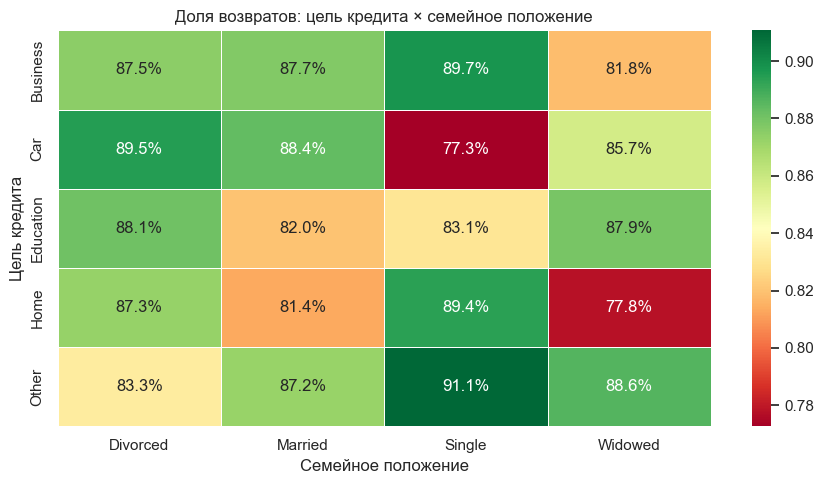

In [5]:
heat = df.pivot_table(values='repaid', index='loan_purpose', columns='family_status', aggfunc='mean')
plt.figure(figsize=(9, 5))
sns.heatmap(heat, annot=True, fmt='.1%', cmap='RdYlGn', linewidths=0.5)
plt.title('Доля возвратов: цель кредита × семейное положение')
plt.xlabel(LABELS['family_status']); plt.ylabel(LABELS['loan_purpose'])
plt.tight_layout(); plt.show()

В сводной таблице разброс заметный: от ~77% возвратов (Car + Single) до ~91%
(Other + Single). Вопрос — это закономерность или шум, если в группе всего 36–65 кредитов?
Проверяю ниже.

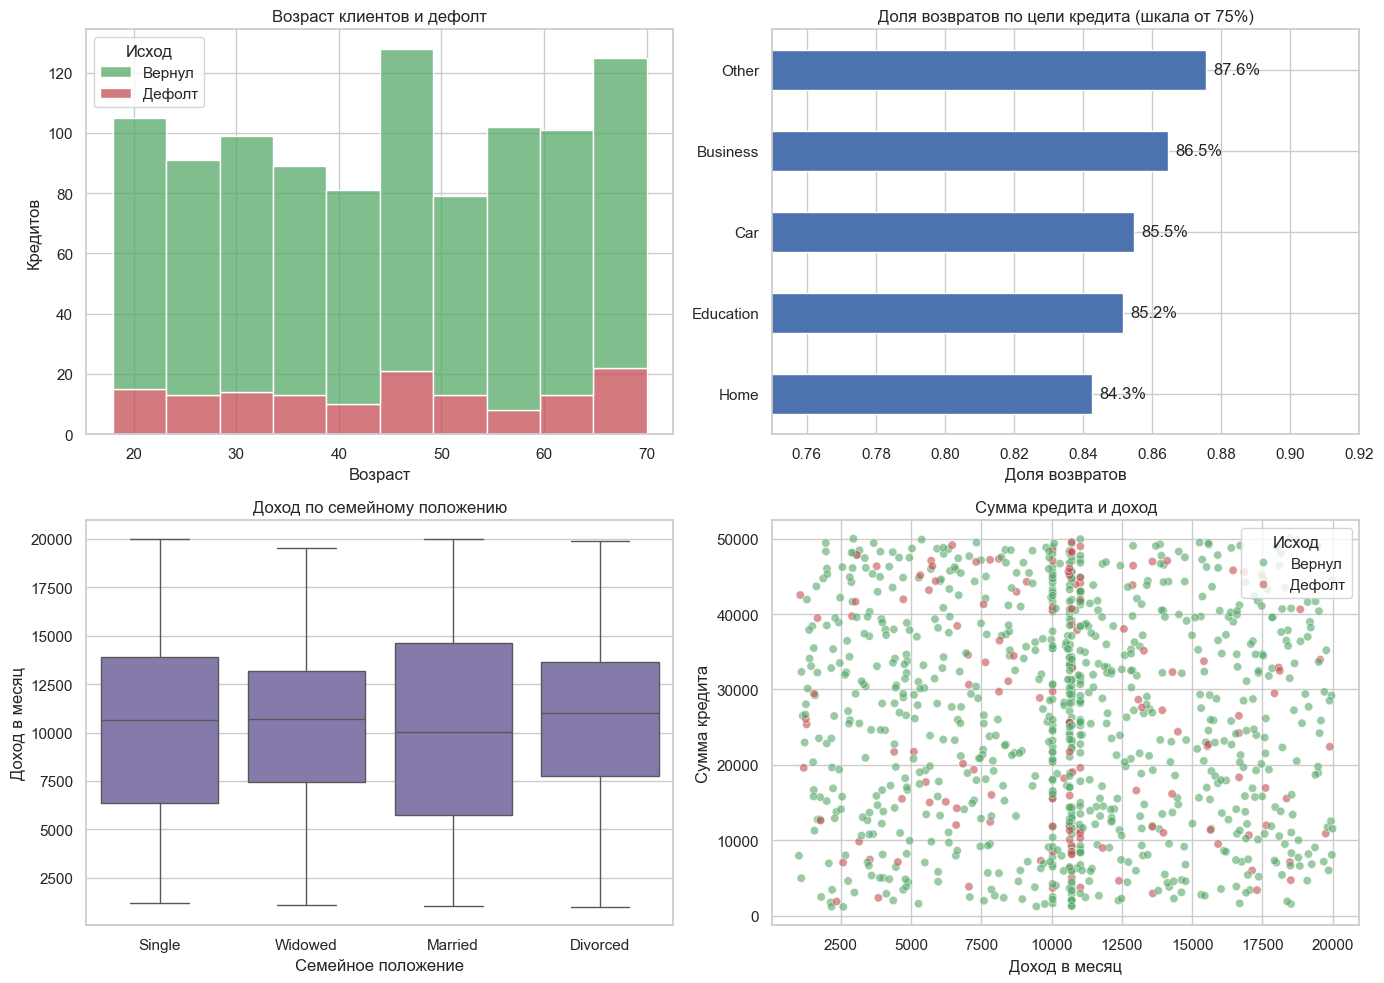

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(data=df, x='age', hue='Исход', hue_order=['Вернул', 'Дефолт'], binwidth=5, multiple='stack',
             palette=['#55A868', '#C44E52'], ax=axes[0, 0])
axes[0, 0].set(title='Возраст клиентов и дефолт', xlabel=LABELS['age'], ylabel='Кредитов')

rate = df.groupby('loan_purpose')['repaid'].mean().sort_values()
rate.plot.barh(color='#4C72B0', ax=axes[0, 1])
axes[0, 1].set(title='Доля возвратов по цели кредита (шкала от 75%)', xlabel='Доля возвратов', ylabel='', xlim=(0.75, 0.92))
for i, v in enumerate(rate):
    axes[0, 1].text(v + 0.002, i, f'{v:.1%}', va='center')

sns.boxplot(data=df, x='family_status', y='income', ax=axes[1, 0], color='#8172B2')
axes[1, 0].set(title='Доход по семейному положению', xlabel=LABELS['family_status'], ylabel=LABELS['income'])

sns.scatterplot(data=df, x='income', y='loan_amount', hue='Исход', hue_order=['Вернул', 'Дефолт'],
                palette=['#55A868', '#C44E52'], alpha=0.6, ax=axes[1, 1])
axes[1, 1].set(title='Сумма кредита и доход', xlabel=LABELS['income'], ylabel=LABELS['loan_amount'])

plt.tight_layout(); plt.show()

Разница между целями кредита — 3 п. п. (шкала начинается с 75%, чтобы её было видно).
Вертикальная полоса на точечном графике около 10 700 — это 216 заполненных медианой
пропусков дохода: заполнение не создаёт новой информации, и это надо держать в голове
при интерпретации. Визуально доход и сумма кредита с дефолтом не связаны.

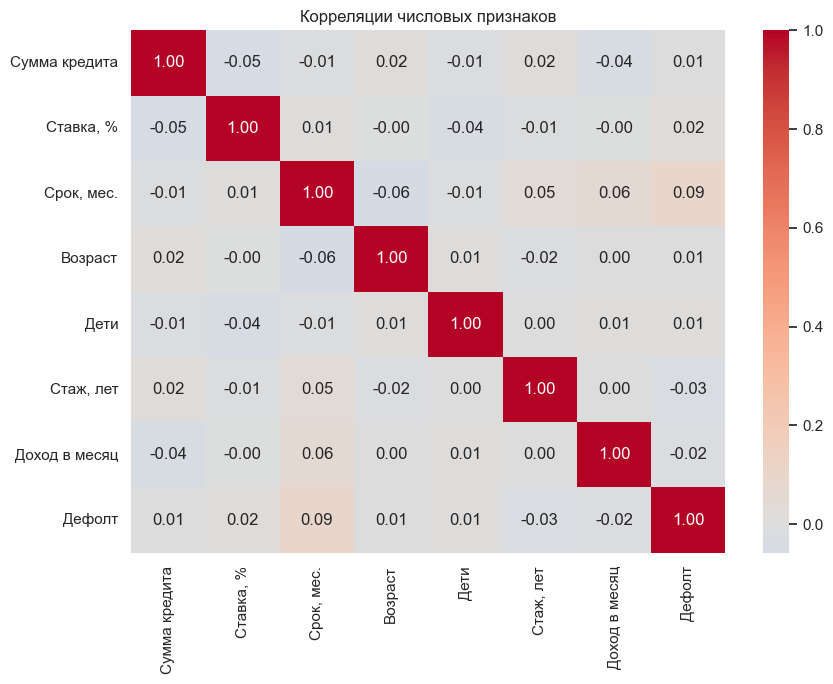

In [7]:
num = ['loan_amount', 'interest_rate', 'term_months', 'age', 'children', 'employment_years', 'income', 'default_flag']
plt.figure(figsize=(9, 7))
sns.heatmap(df[num].rename(columns=LABELS).corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляции числовых признаков'); plt.tight_layout(); plt.show()

## 4. Статистическая проверка

Исход бинарный (дефолт 0/1), поэтому основной инструмент — тест χ² и логистическая
регрессия. Двухфакторный дисперсионный анализ и попарное сравнение Тьюки — как
дополнительная проверка. Уровень значимости α = 0,05.

In [8]:
print('=== χ²: категориальные признаки и дефолт ===')
for col in ['loan_purpose', 'family_status']:
    chi2, p, dof, _ = stats.chi2_contingency(pd.crosstab(df[col], df['default_flag']))
    print(f'{LABELS[col]:<20} χ²={chi2:6.2f}  df={dof}  p={p:.3f}')
chi2, p, dof, _ = stats.chi2_contingency(pd.crosstab([df['loan_purpose'], df['family_status']], df['default_flag']))
print(f'{"Цель × положение":<20} χ²={chi2:6.2f}  df={dof}  p={p:.3f}')

=== χ²: категориальные признаки и дефолт ===
Цель кредита         χ²=  1.05  df=4  p=0.901
Семейное положение   χ²=  0.69  df=3  p=0.875
Цель × положение     χ²= 11.73  df=19  p=0.897


In [9]:
full = logit('default_flag ~ C(loan_purpose) + C(family_status) + loan_amount + interest_rate'
             ' + term_months + age + children + employment_years + income', data=df).fit(disp=0)
print(full.summary2().tables[1][['Coef.', 'P>|z|']].round(4))

                               Coef.   P>|z|
Intercept                    -2.6379  0.0000
C(loan_purpose)[T.Car]        0.1132  0.7009
C(loan_purpose)[T.Education]  0.0762  0.7892
C(loan_purpose)[T.Home]       0.1932  0.4982
C(loan_purpose)[T.Other]     -0.0839  0.7786
C(family_status)[T.Married]   0.1908  0.4596
C(family_status)[T.Single]    0.1209  0.6488
C(family_status)[T.Widowed]   0.2209  0.4019
loan_amount                   0.0000  0.7881
interest_rate                 0.0127  0.5428
term_months                   0.0166  0.0044
age                           0.0018  0.7606
children                      0.0316  0.5634
employment_years             -0.0095  0.2935
income                       -0.0000  0.5384


In [10]:
anova = anova_lm(ols('repaid ~ C(loan_purpose) * C(family_status)', data=df).fit(), typ=2)
print('=== Двухфакторный дисперсионный анализ ===')
print(anova.round(4))
print()
print(pairwise_tukeyhsd(df['repaid'], df['family_status']))

=== Двухфакторный дисперсионный анализ ===
                                    sum_sq     df       F  PR(>F)
C(loan_purpose)                     0.1307    4.0  0.2660  0.8999
C(family_status)                    0.0867    3.0  0.2353  0.8718
C(loan_purpose):C(family_status)    1.2137   12.0  0.8232  0.6266
Residual                          120.4071  980.0     NaN     NaN



 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1   group2 meandiff p-adj   lower  upper  reject
------------------------------------------------------
Divorced Married  -0.0188 0.9277 -0.0977 0.0601  False
Divorced  Single  -0.0099 0.9891 -0.0903 0.0705  False
Divorced Widowed  -0.0243 0.8685 -0.1056  0.057  False
 Married  Single    0.009 0.9916 -0.0709 0.0888  False
 Married Widowed  -0.0055 0.9981 -0.0862 0.0752  False
  Single Widowed  -0.0144 0.9693 -0.0966 0.0677  False
------------------------------------------------------


In [11]:
print('=== Связь числовых признаков с дефолтом (точечно-бисериальная корреляция) ===')
for col in ['loan_amount', 'interest_rate', 'term_months', 'age', 'children', 'employment_years', 'income']:
    r, p = stats.pointbiserialr(df['default_flag'], df[col])
    print(f'{LABELS[col]:<16} r={r:+.3f}  p={p:.3f}  {"значимо" if p < 0.05 else ""}')

d, nd = df.loc[df.default_flag == 1, 'term_months'], df.loc[df.default_flag == 0, 'term_months']
pooled = np.sqrt(((len(d) - 1) * d.var() + (len(nd) - 1) * nd.var()) / (len(d) + len(nd) - 2))
print(f'\nСрок кредита: {d.mean():.1f} мес. у дефолтных vs {nd.mean():.1f} у вернувших, '
      f'd Коэна = {(d.mean() - nd.mean()) / pooled:.2f}')

=== Связь числовых признаков с дефолтом (точечно-бисериальная корреляция) ===
Сумма кредита    r=+0.006  p=0.848  
Ставка, %        r=+0.019  p=0.540  
Срок, мес.       r=+0.088  p=0.005  значимо
Возраст          r=+0.006  p=0.855  
Дети             r=+0.015  p=0.637  
Стаж, лет        r=-0.028  p=0.377  
Доход в месяц    r=-0.015  p=0.626  

Срок кредита: 36.8 мес. у дефолтных vs 32.8 у вернувших, d Коэна = 0.25


### Проверка нормальности

Часть методов выше предполагает нормальность. Проверяю ключевые непрерывные признаки
тестом Колмогорова — Смирнова (параметры нормали оценены по выборке, поэтому тест
строже обычного — по сути критерий Лиллиефорса) и пробую преобразования √x и ln x.

In [12]:
def ks(x):
    x = np.asarray(x, float)
    return stats.kstest(x, 'norm', args=(x.mean(), x.std(ddof=1)))

rows = []
for col in ['loan_amount', 'income']:
    x = df[col]
    for name, t in [('исходные', x), ('√x', np.sqrt(x)), ('ln x', np.log(x))]:
        res = ks(t)
        rows.append({'признак': LABELS[col], 'преобразование': name,
                     'KS': round(res.statistic, 3), 'p': res.pvalue, 'нормальное': res.pvalue >= 0.05})
    print(f'{LABELS[col]}: асимметрия {stats.skew(x):+.2f}, эксцесс {stats.kurtosis(x):+.2f}')
pd.DataFrame(rows)

Сумма кредита: асимметрия -0.05, эксцесс -1.25
Доход в месяц: асимметрия -0.01, эксцесс -0.77


,признак,преобразование,KS,p,нормальное
0,Сумма кредита,исходные,0.072,6.651721e-05,False
1,Сумма кредита,√x,0.090,1.955891e-07,False
2,Сумма кредита,ln x,0.138,4.274861e-17,False
3,Доход в месяц,исходные,0.092,9.565921e-08,False
4,Доход в месяц,√x,0.147,3.252639e-19,False
5,Доход в месяц,ln x,0.200,1.678835e-35,False


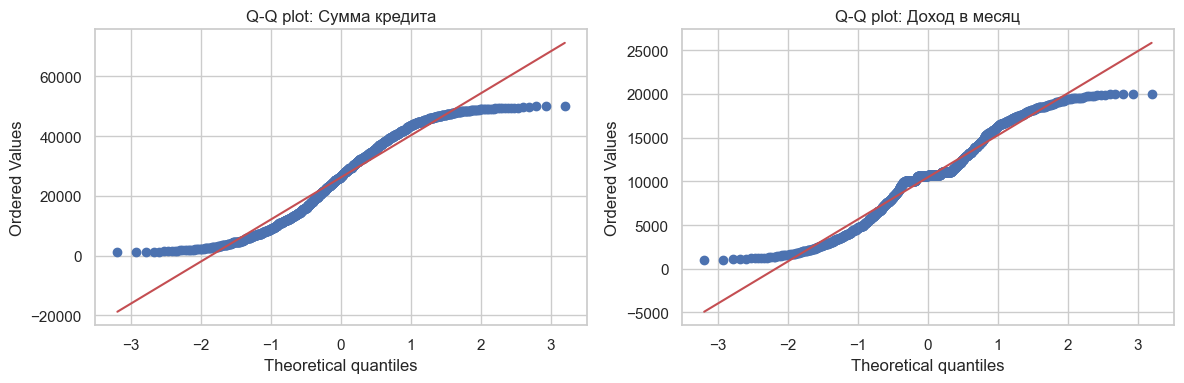

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['loan_amount', 'income']):
    stats.probplot(df[col], dist='norm', plot=ax)
    ax.set_title(f'Q-Q plot: {LABELS[col]}')
plt.tight_layout(); plt.show()

Оба признака распределены почти равномерно (отрицательный эксцесс), поэтому
преобразования, рассчитанные на длинный правый хвост, нормальности не дают.
Вывод для метода: опираться на χ² и логистическую регрессию, а для сравнения
групп по числовым признакам — на непараметрические тесты.

## 5. Выводы

1. **Цель кредита и семейное положение на дефолт статистически не влияют** —
   ни по отдельности, ни в сочетании (χ², логистическая регрессия, дисперсионный анализ,
   Тьюки: все p > 0,05). Разница 77–91% в сводной таблице — в пределах случайных
   колебаний при таком объёме групп. Строить на ней правила скоринга нельзя.
2. **Доход, возраст, сумма кредита, стаж и число детей с дефолтом не связаны**
   (|r| < 0,05, p > 0,05).
3. **Единственный значимый сигнал — срок кредита**: длинные кредиты чуть чаще уходят
   в дефолт (r ≈ 0,09, p ≈ 0,005, d Коэна ≈ 0,25 — эффект слабый).
4. **Практический вывод:** доступных признаков недостаточно для скоринга. Нужны данные
   о кредитной истории, долговой нагрузке, поведении по счёту — или выборка больше.

Главное, чему учит этот кейс: различия в сводной таблице выглядят убедительно,
но без статистической проверки легко принять шум за закономерность.